# Project Overview: Predictive Customer Lifetime Value & Segmentation
This project aims to analyze purchasing behavior and predict future **Customer Lifetime Value (CLV)** using a transaction dataset. The analysis follows a high-impact data science workflow:

- **Cohort Analysis**: To visualize the macro-trend of customer retention rates over time.
- **Probabilistic Models (BG/NBD & Gamma-Gamma)**: To predict individual purchase frequency and expected monetary value for the next 90 days.
- **Gaussian Mixture Model (GMM)**: To segment customers into 5 distinct segments based on business potential and churn risk, providing actionable marketing insights.

**Data Source**: Chocolate Sales Dataset (2023-2024) >> https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024

## 1. Setup & Environment Configuration

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture


## 2. Data Ingestion & Preprocessing
- **Process**: Standardize column names (Snake Case), convert date types and inspect data integrity.
- **Goal**: Ensure a clean foundation for statistical modeling.

In [2]:
# Load Dataset from Kaggle
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'ssssws/chocolate-sales-dataset-2023-2024','sales.csv')

# Clean and standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')

# Format date column
df['order_date'] = pd.to_datetime(df['order_date'])

print(df.info())
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 83.9+ MB
None


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40
...,...,...,...,...,...,...,...,...,...,...,...
999995,0RD00999996,2023-04-15,P0103,S053,C044763,4,7.45,0.00,29.80,17.27,12.53
999996,0RD00999997,2023-05-26,P0094,S058,C004441,2,6.09,0.00,12.18,7.81,4.37
999997,0RD00999998,2023-07-05,P0097,S041,C044879,3,6.09,0.00,18.27,10.11,8.16
999998,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.00,4.90,2.56,2.34


In [3]:
# Check transaction have not group
df['customer_id'].value_counts().to_frame().head()


,count
customer_id,
C044952,41
C005182,39
C033309,39
C009919,38
C046258,38


## 3. Customer Retention Analysis (Cohort Analysis)
 - **Objective**: Track how many customers return to purchase in subsequent months after their first transaction.
 - **Business Value**: Identify "drop-off" points and evaluate the effectiveness of acquisition campaigns.

In [4]:
# Create monthly transaction periods
df['transaction_year_month'] = df['order_date'].dt.to_period('M')

# Define Cohort Month (first purchase month) for each customer
df['cohort_year_month'] = df.groupby('customer_id')['transaction_year_month'].transform('min')
df['cohort_index'] = (df['transaction_year_month'] - df['cohort_year_month']).apply(lambda x: x.n)

# Aggregate unique customers per cohort index
cohort_data = df.groupby(['cohort_year_month','cohort_index'])['customer_id'].nunique().reset_index()
cohort_count = pd.pivot_table(data= cohort_data, index='cohort_year_month', columns='cohort_index', values='customer_id')

# Convert counts to retention percentage
cohort_size = cohort_count.iloc[:,0]
cohort_percent = cohort_count.divide(cohort_size, axis=0)

cohort_percent


cohort_index,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort_year_month,,,,,,,,,,,,,,,,,,,,,
2023-01,1.0,0.535283,0.575013,0.556948,0.575497,0.560339,0.571933,0.571725,0.561897,0.575913,...,0.570272,0.560408,0.574148,0.559785,0.572175,0.572452,0.562000,0.568472,0.558090,0.564907
2023-02,1.0,0.573212,0.558677,0.571518,0.556001,0.576690,0.575531,0.559836,0.567059,0.558855,...,0.556804,0.571250,0.549581,0.568307,0.575976,0.564741,0.578652,0.559925,0.570804,NaN
2023-03,1.0,0.552920,0.579823,0.551858,0.564779,0.567257,0.567434,0.577345,0.571858,0.571504,...,0.573274,0.556814,0.584248,0.558761,0.552743,0.570088,0.550973,0.572566,NaN,NaN
2023-04,1.0,0.572671,0.559006,0.569772,0.571014,0.568116,0.554037,0.559834,0.576398,0.564389,...,0.554037,0.568944,0.573085,0.553623,0.575155,0.566046,0.574327,NaN,NaN,NaN
2023-05,1.0,0.558795,0.560739,0.543246,0.569485,0.576288,0.571429,0.574344,0.570457,0.540330,...,0.582119,0.595724,0.579203,0.567541,0.566569,0.585034,NaN,NaN,NaN,NaN
2023-06,1.0,0.581236,0.574371,0.599542,0.558352,0.530892,0.551487,0.599542,0.540046,0.572082,...,0.578947,0.560641,0.572082,0.576659,0.558352,NaN,NaN,NaN,NaN,NaN
2023-07,1.0,0.538860,0.559585,0.559585,0.585492,0.585492,0.616580,0.512953,0.590674,0.533679,...,0.601036,0.512953,0.538860,0.585492,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,1.0,0.583333,0.625000,0.510417,0.510417,0.625000,0.614583,0.593750,0.541667,0.541667,...,0.572917,0.500000,0.552083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,1.0,0.578947,0.500000,0.526316,0.578947,0.578947,0.736842,0.394737,0.552632,0.473684,...,0.447368,0.710526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


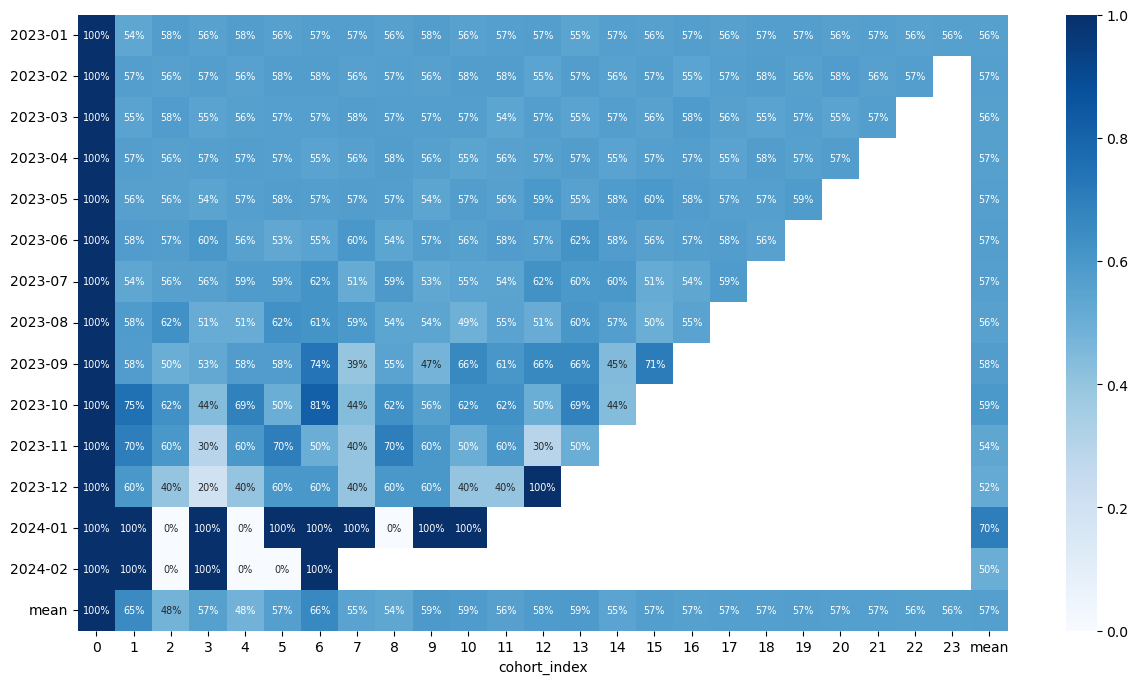

In [5]:
# Prepare visualization with a 'mean' column and row for benchmarking
cohort_vis = cohort_percent.copy()
cohort_vis.loc[cohort_vis.index == '2024-01',[2,4,8]] = cohort_vis.loc[cohort_vis.index == '2024-01',[2,4,8]].fillna(0)
cohort_vis.loc[cohort_vis.index == '2024-02',[2,4,5]] = cohort_vis.loc[cohort_vis.index == '2024-02',[2,4,5]].fillna(0)
cohort_vis['mean'] = cohort_vis.iloc[:,1:].mean(axis=1)
mean_row = cohort_vis.mean().to_frame().T
mean_row.index = ['mean']
cohort_vis = pd.concat([cohort_vis,mean_row],axis= 0)

# Plot Retention Heatmap
plt.figure(figsize=(15,8))
sns.heatmap(cohort_vis, cmap='Blues', annot=True, annot_kws={'size':7}, fmt='.0%')
plt.show()


**Key Finding**
- The overall retention rate stabilizes at approximately **57%**. The most significant drop-off occurs in the second month (Month 1), where retention dips to an average of **65%**.
- A key highlight is the **Jan 2024** cohort, which shows a high retention rate of **70%**. Interestingly, there are some gaps where no customers returned to buy in certain months.

## 4. RFM Feature Engineering for Lifetimes Modeling
- **Process**: Transform raw transactions into Recency, Frequency, T (Age), and Monetary value.
- **Note**: Monetary value represents the **average value of repeat purchases** to satisfy Gamma-Gamma model requirements.

In [6]:
# Create RFM table
rfm = summary_data_from_transaction_data(
    df
    , customer_id_col = 'customer_id'
    , datetime_col= 'order_date'
    , monetary_value_col= 'revenue'
    , observation_period_end= df['order_date'].max()
)

rfm


,frequency,recency,T,monetary_value
customer_id,,,,
C000001,23.0,675.0,700.0,17.388696
C000002,23.0,684.0,706.0,24.953913
C000003,23.0,674.0,719.0,27.447391
C000004,16.0,688.0,713.0,28.496250
C000005,31.0,712.0,723.0,25.899355
...,...,...,...,...
C049996,18.0,668.0,668.0,28.488889
C049997,14.0,562.0,580.0,30.592857
C049998,21.0,702.0,720.0,28.611429


## 5. Probabilistic Activity Modeling (BG/NBD)
- **Model**: BG/NBD is used to estimate the **Probability of being "Alive" (Prob_Active)** for each customer.
- **Strategic Extension**: Due to the high density of active users, The observation period was manually extended (+5 months) to see more realistic churn trends.

In [7]:
# Fit BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    rfm['frequency']
    , rfm['recency']
    , rfm['T']
)

# Calculate P(Alive)
rfm_prob_active = rfm.copy()
rfm_prob_active['prob_active'] = bgf.conditional_probability_alive(
    rfm_prob_active['frequency']
    , rfm_prob_active['recency']
    , rfm_prob_active['T']
)

rfm_prob_active['prob_active'].describe()


count    5.000000e+04
mean     1.000000e+00
std      2.708607e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: prob_active, dtype: float64

**Note** : Since the probability of customers being active was 100% for everyone, we extended the observation period by 5 months to make the data more realistic.

In [8]:
# Change observation_period_end to more for increase prob_active realistic 
rfm = summary_data_from_transaction_data(
    df
    , customer_id_col = 'customer_id'
    , datetime_col= 'order_date'
    , monetary_value_col= 'revenue'
    , observation_period_end= '2025-04-30'
)

# Fit BG/NBD model with synthetic extension for predictive sensitivity
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    rfm['frequency']
    , rfm['recency']
    , rfm['T']
)

# Calculate P(Alive) again
rfm_prob_active = rfm.copy()
rfm_prob_active['prob_active'] = bgf.conditional_probability_alive(
    rfm_prob_active['frequency']
    , rfm_prob_active['recency']
    , rfm_prob_active['T']
)

rfm_prob_active['prob_active'].describe()


count    50000.000000
mean         0.785732
std          0.174293
min          0.000869
25%          0.743524
50%          0.848798
75%          0.899167
max          0.957850
Name: prob_active, dtype: float64

## 6. Predicting Purchase Frequency for the Next 90 Days
- **Process**: Use the parameters from the BG/NBD model to calculate the Expected Transactions for each customer.
- **Business Value**: This information helps in inventory planning and forecasting store or website traffic in advance.

In [9]:
# Predict Expected Transactions for the next 90 days
rfm_n_next_3M = rfm_prob_active.copy()
rfm_n_next_3M['n_purchase_next_3M'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90
    , rfm_n_next_3M['frequency']
    , rfm_n_next_3M['recency']
    , rfm_n_next_3M['T']
).round()

rfm_n_next_3M


,frequency,recency,T,monetary_value,prob_active,n_purchase_next_3M
customer_id,,,,,,
C000001,23.0,675.0,820.0,17.388696,0.793577,2.0
C000002,23.0,684.0,826.0,24.953913,0.813115,2.0
C000003,23.0,674.0,839.0,27.447391,0.689588,2.0
C000004,16.0,688.0,833.0,28.496250,0.896382,2.0
C000005,31.0,712.0,843.0,25.899355,0.743541,2.0
...,...,...,...,...,...,...
C049996,18.0,668.0,788.0,28.488889,0.920559,2.0
C049997,14.0,562.0,700.0,30.592857,0.885280,2.0
C049998,21.0,702.0,840.0,28.611429,0.865933,2.0


## 7. Monetary Value Prediction (Gamma-Gamma)
- **Process**: Filter for repeat customers and use the Gamma-Gamma model to find the relationship between purchase frequency and spending.
- **Business Value**: Predicts future revenue from current customers more accurately than using simple averages.

In [10]:
# Filter for repeat customers (Frequency > 0)
rfm_expect_sales = rfm_n_next_3M[rfm_n_next_3M['frequency'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(
    rfm_expect_sales['frequency']
    , rfm_expect_sales['monetary_value']
)

# Predict Expected Mean Sales
rfm_expect_sales['expected_mean_sales'] = ggf.conditional_expected_average_profit(
    rfm_expect_sales['frequency']
    , rfm_expect_sales['monetary_value']
)

# Logic: If predicted n_purchase is 0, expected_mean_sales should reflect 0 for the forecast period
rfm_expect_sales.loc[rfm_expect_sales['n_purchase_next_3M'] == 0, 'expected_mean_sales'] = 0

rfm_expect_sales


,frequency,recency,T,monetary_value,prob_active,n_purchase_next_3M,expected_mean_sales
customer_id,,,,,,,
C000001,23.0,675.0,820.0,17.388696,0.793577,2.0,17.595019
C000002,23.0,684.0,826.0,24.953913,0.813115,2.0,25.015437
C000003,23.0,674.0,839.0,27.447391,0.689588,2.0,27.461190
C000004,16.0,688.0,833.0,28.496250,0.896382,2.0,28.487302
C000005,31.0,712.0,843.0,25.899355,0.743541,2.0,25.931736
...,...,...,...,...,...,...,...
C049996,18.0,668.0,788.0,28.488889,0.920559,2.0,28.481090
C049997,14.0,562.0,700.0,30.592857,0.885280,2.0,30.517545
C049998,21.0,702.0,840.0,28.611429,0.865933,2.0,28.602156


## 8. Estimating Customer Lifetime Value (CLV)
- **Process**: Multiply the expected number of purchases by the expected average spend. A Discount Rate (1% per month) is applied to calculate the Present Value of future revenue.
- **Business Value**: CLV acts as a "spending limit" for marketing. For example, if a customer is predicted to generate 50 THB in 3 months, we should not spend more than that on ads or promotions to protect the company's Profit Margin.

In [11]:
# Calculate 3-Month Customer Lifetime Value (CLV)
clv = rfm_expect_sales.copy()
clv['clv_3M'] = ggf.customer_lifetime_value(
    bgf
    , clv['frequency']
    , clv['recency']
    , clv['T']
    , clv['monetary_value']
    , time=3
    , discount_rate=0.01 
)

# Logic: If predicted purchase is 0, CLV should reflect 0 for the forecast period
clv.loc[clv['n_purchase_next_3M'] == 0, 'clv_3M'] = 0

clv.sort_values(by= 'clv_3M', ascending= False)


,frequency,recency,T,monetary_value,prob_active,n_purchase_next_3M,expected_mean_sales,clv_3M
customer_id,,,,,,,,
C028269,21.0,714.0,848.0,45.087619,0.881940,2.0,44.733585,85.646635
C019742,32.0,696.0,817.0,34.091875,0.774612,3.0,34.009944,84.862723
C001263,26.0,697.0,822.0,36.708846,0.845914,2.0,36.563921,82.643491
C000888,27.0,725.0,845.0,35.346667,0.867714,2.0,35.229294,82.485018
C023205,31.0,687.0,807.0,32.888387,0.790090,3.0,32.821026,82.047136
...,...,...,...,...,...,...,...,...
C006436,22.0,606.0,841.0,26.050909,0.211572,0.0,0.000000,0.000000
C032233,16.0,448.0,811.0,19.448750,0.017810,0.0,0.000000,0.000000
C042005,17.0,496.0,796.0,30.506471,0.075377,0.0,0.000000,0.000000


## 9. Customer Segmentation (GMM Clustering)

### 9.1 Check Distribution Charactor
- **Process**: Create an initial scatterplot of 'prob_active' and 'clv_3M' to see if these two features can be used to group customers effectively.

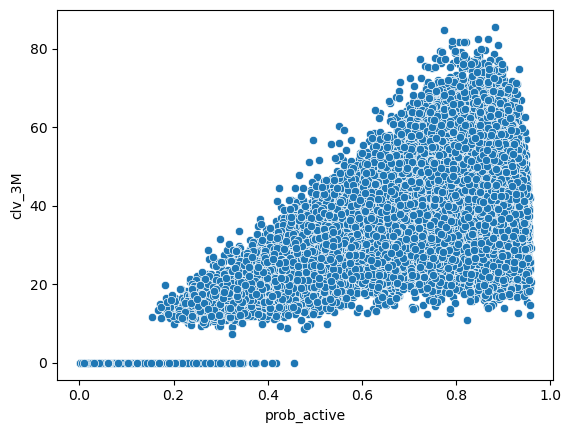

In [12]:
sns.scatterplot(clv, x='prob_active', y='clv_3M')
plt.show()


**Note**: Gaussian Mixture Model (GMM) is selected over K-Means due to its ability to handle **Heteroscedasticity** (elliptical data distribution) in the $P(Alive)$ and $CLV$ feature space.

### 9.2 GMM Model
- **Optimal K**: Determining the number of clusters using the **Bayesian Information Criterion (BIC)**.

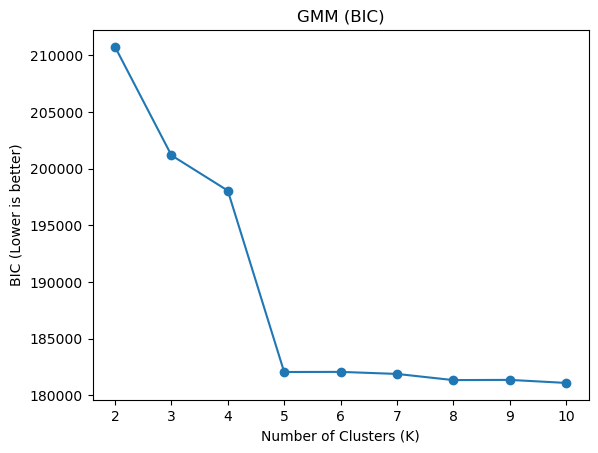

In [13]:

# เติม Missing valu column 'prob_active', 'clv_3M' เพื่อให้พร้อมสำหรับการ visualize
# clv[['expected_mean_sales','clv_3M']] = clv[['expected_mean_sales','clv_3M']].fillna(0)

segment = clv.copy()

# Feature Scaling for GMM
ss = StandardScaler()
segment['prob_active_cale'] = ss.fit_transform(segment[['prob_active']])
segment['clv_3M_scale'] = ss.fit_transform(segment[['clv_3M']])

# Find Optimal Clusters using BIC
n_components = np.arange(2, 11)
test_n_clusters = [GaussianMixture(n, random_state=1).fit(segment[['prob_active_cale','clv_3M_scale']])
                   for n in n_components]

plt.plot(n_components, [m.bic(segment[['prob_active_cale','clv_3M_scale']]) for m in test_n_clusters], 'o-')
plt.title('GMM (BIC)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('BIC (Lower is better)')
plt.show()


**Note**: After using the BIC (Bayesian Information Criterion) to evaluate the GMM model, the results show that 5 clusters is the optimal number for grouping our customers.

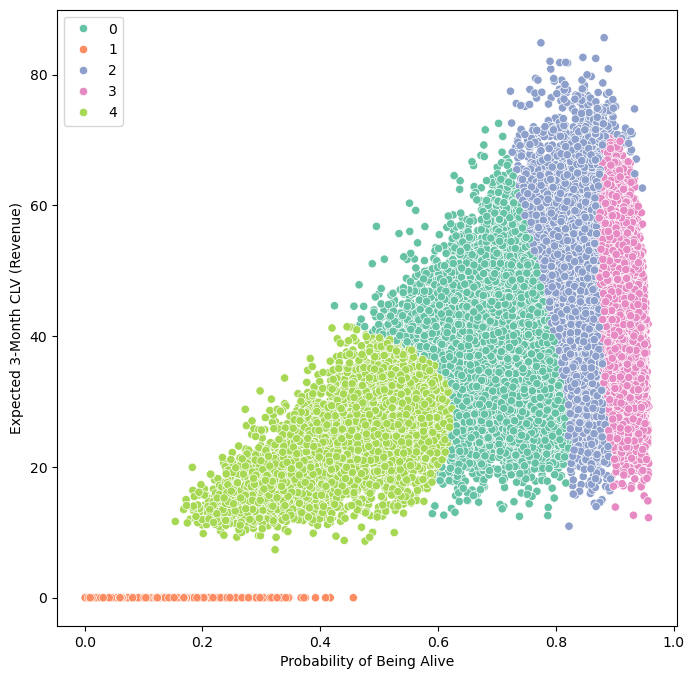

In [14]:
# Build and Predict Clusters
gmm = GaussianMixture(n_components=5, random_state=1)
gmm.fit(segment[['prob_active_cale','clv_3M_scale']])
segment['segment'] = gmm.predict(segment[['prob_active_cale','clv_3M_scale']])

plt.figure(figsize=(8,8))
sns.scatterplot(segment, x='prob_active', y='clv_3M', hue='segment', palette='Set2')
plt.legend(fontsize=10)
plt.xlabel('Probability of Being Alive')
plt.ylabel('Expected 3-Month CLV (Revenue)')
plt.show()


**Key Finding**

After clustering with the GMM model, the segments are mapped into the following 5 groups based on their behavior and potential value:

- Segment 0: Need Attention – These customers show signs of leaving. Strategy: Send limited-time offers or recommend new products based on their past history to win them back.
- Segment 1: Lost – Customers who have likely churned. Strategy: No immediate action required; focus resources on other groups.
- Segment 2: Loyal Customers – Your most reliable group. Strategy: Focus on up-selling higher-value products, asking for reviews, or sending small gifts to maintain the relationship.
- Segment 3: Promising – New or high-potential customers. Strategy: Offer loyalty programs, provide personalized recommendations, and engage them with direct communication.
- Segment 4: Lower Customers – Low-frequency or low-spend buyers. Strategy: Use "reach-out" marketing campaigns to try and revive their interest in the brand.

Reference: https://how-many-steps-inc.webflow.io/rfm-segmentation-overview

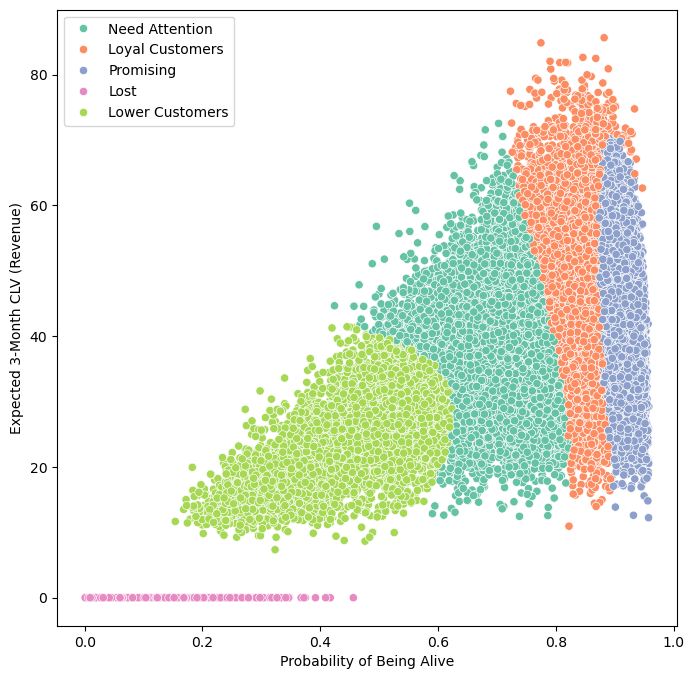

In [15]:
# Map segments to descriptive labels
segment['segment_name'] = segment['segment'].map({
    0:'Need Attention'
    , 1:'Lost'
    , 2:'Loyal Customers'
    , 3:'Promising'
    , 4:'Lower Customers'
})

# Visualize Segments
plt.figure(figsize=(8,8))
sns.scatterplot(segment, x='prob_active', y='clv_3M', hue='segment_name', palette='Set2')
plt.legend(fontsize=10)
plt.xlabel('Probability of Being Alive')
plt.ylabel('Expected 3-Month CLV (Revenue)')
plt.show()


## 10. Strategic Business Analysis

### 10.1 Merging Segmentation Results with Metadata

In [16]:
# Merge analytical results with original transaction attributes
df_add = df.merge(segment[['segment_name','clv_3M']].reset_index(), on= 'customer_id', how='left')

# Load additional product/store metadata
df_product = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'ssssws/chocolate-sales-dataset-2023-2024', 'products.csv')
df_add = df_add.merge(df_product[['product_id','category']].rename(columns={'category':'product_category'}), on= 'product_id', how='left')

df_store = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, 'ssssws/chocolate-sales-dataset-2023-2024', 'stores.csv')
df_add = df_add.merge(df_store[['store_id','store_type']], on= 'store_id', how='left')


### 10.2 Customer Value Distribution & Strategic Budgeting

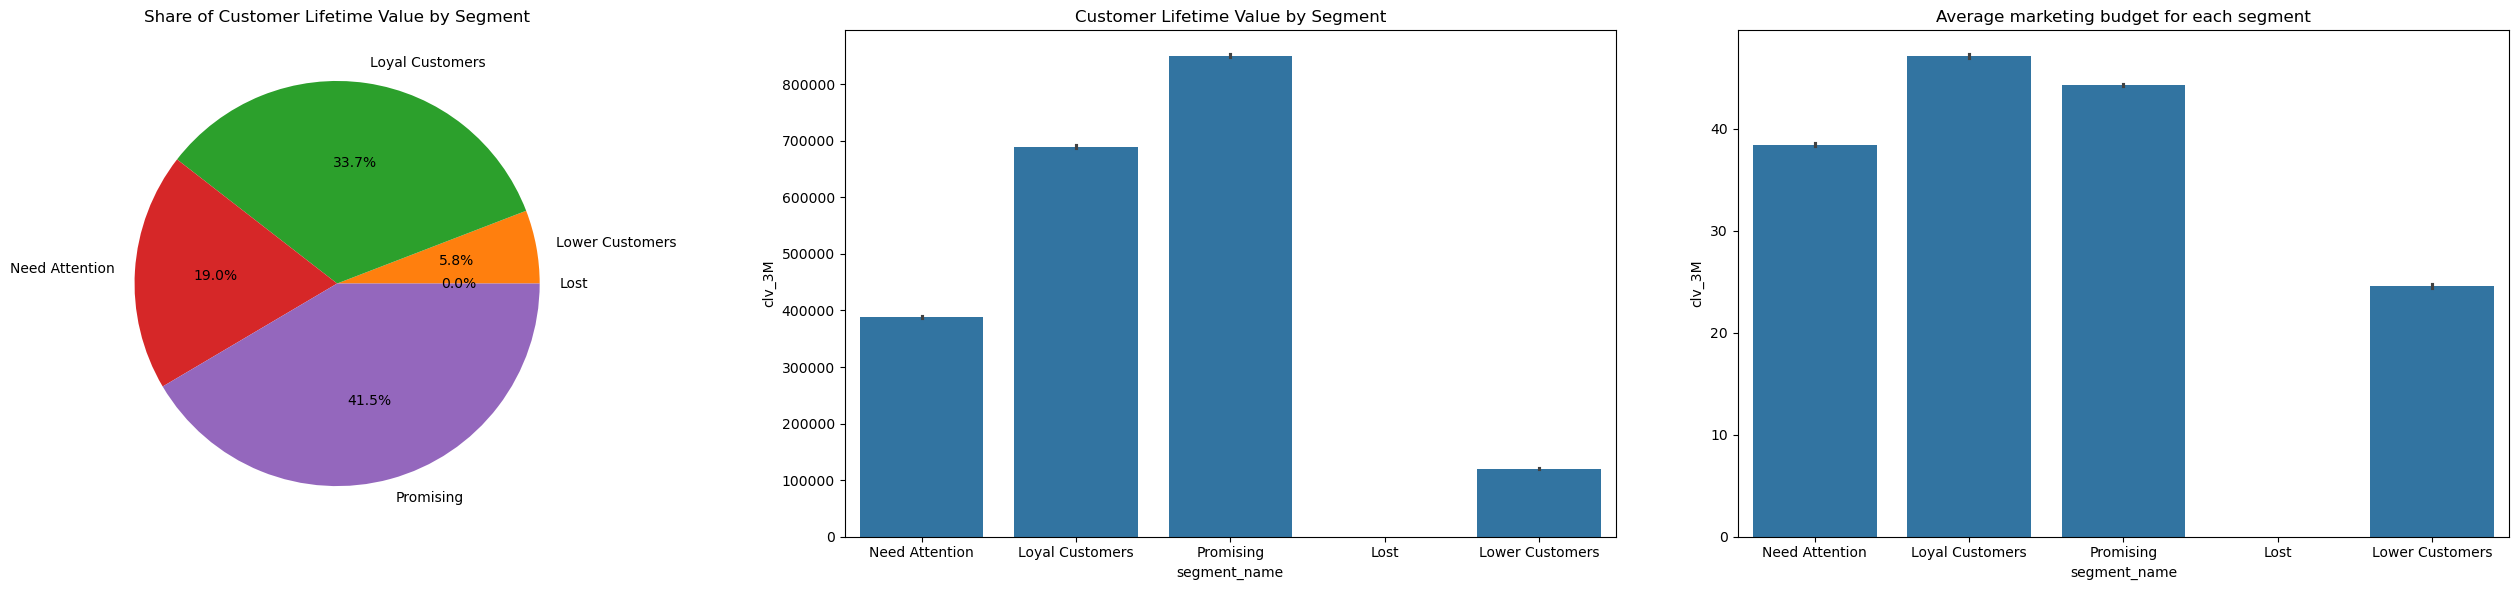

In [17]:
# Visualizing Segment Contributions
fig, ax = plt.subplots(1,3, figsize=(26,6))

# CLV Share
clv_segment = segment.groupby('segment_name')['clv_3M'].sum()

ax[0].pie(
    clv_segment
    , labels=clv_segment.index
    , autopct='%1.1f%%'
)
ax[0].set_title('Share of Customer Lifetime Value by Segment')

# Total CLV per Segment
sns.barplot(
    segment
    , x='segment_name'
    , y='clv_3M'
    , estimator='sum'
    , ax=ax[1]
)
ax[1].set_title('Customer Lifetime Value by Segment')

# Average CLV (Marketing Budget Benchmark)
sns.barplot(
    segment
    , x='segment_name'
    , y='clv_3M'
    , estimator='mean'
    , ax=ax[2]
)
ax[2].set_title('Average marketing budget for each segment')

plt.tight_layout()
plt.show()


**Key Finding**
- **CLV Contribution**: The **Promising segment** contributes the highest total CLV, accounting for 42% of the total predicted value, followed by **Loyal Customers** at 34%.
- **Segment Efficiency**: Although **Promising segment** has the highest total value, **Loyal Customers segment** yield the highest Average CLV per person, making them the most efficient group for long-term value.
- **Marketing Strategy**: Average CLV per segment can be used as a benchmark for marketing budgets. However, for better ROI, the business should focus on personalized marketing at the individual level.

### 10.3 Revenue vs. Profitability Analysis by Segment

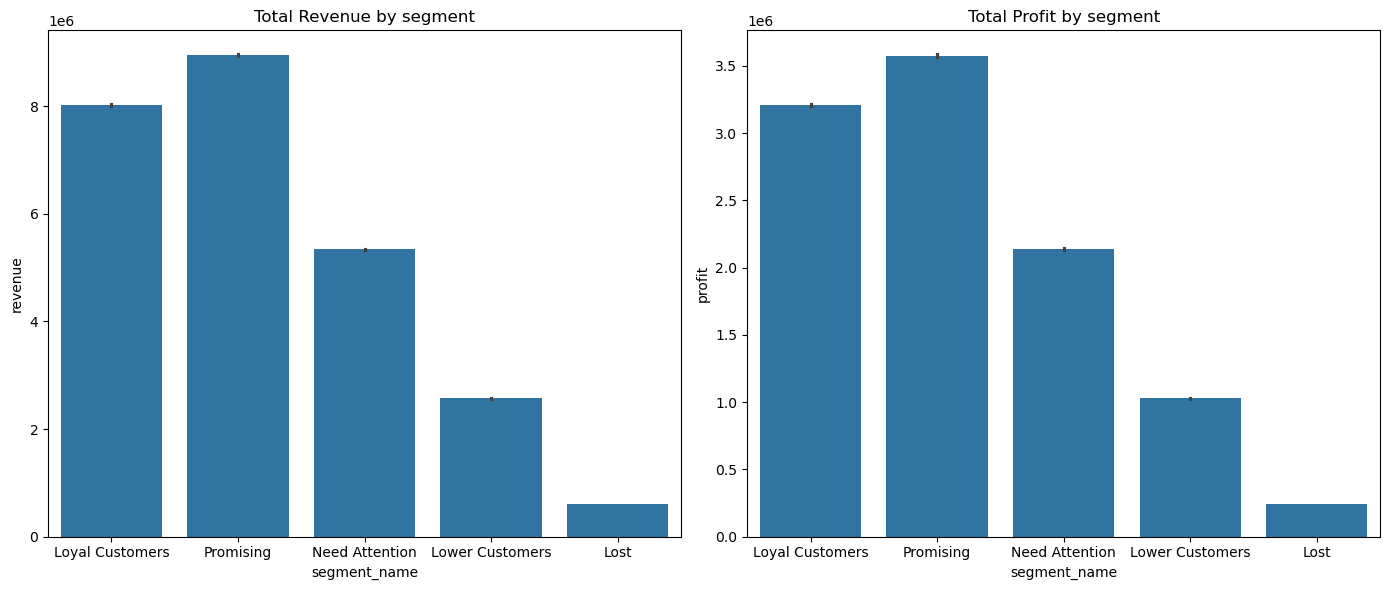

In [18]:

fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.barplot(
    df_add
    , x='segment_name'
    , y='revenue'
    , estimator='sum'
    , ax=ax[0]
)
ax[0].set_title('Total Revenue by segment')

sns.barplot(
    df_add
    , x='segment_name'
    , y='profit'
    , estimator='sum'
    , ax=ax[1]
)
ax[1].set_title('Total Profit by segment')

plt.tight_layout()
plt.show()


**Key Finding**
- **Consistent Performance**: Revenue and Profit share a similar pattern across all segments. The Promising segment is the top performer, followed by Loyal Customers and Need Attention, respectively.

### 10.4 Customer Purchasing Preferences: Store Types & Product Categories


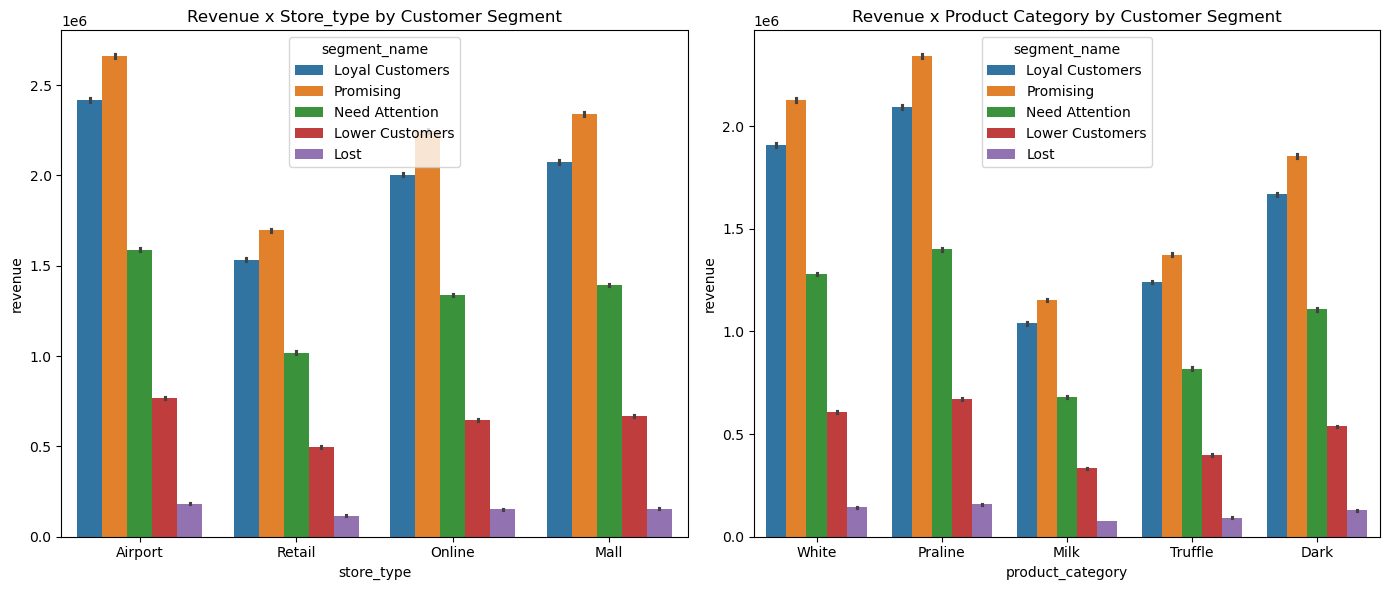

In [19]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.barplot(
    df_add
    , x='store_type'
    , y='revenue'
    , hue='segment_name'
    , estimator='sum'
    , ax=ax[0]
)
ax[0].set_title('Revenue x Store_type by Customer Segment')

sns.barplot(
    df_add
    , x='product_category'
    , y='revenue'
    , hue='segment_name'
    , estimator='sum'
    , ax=ax[1]  
)
ax[1].set_title('Revenue x Product Category by Customer Segment')

plt.tight_layout()
plt.show()


**Key Finding**
- **Market Dominance**: The **Promising segment** is the primary revenue driver across all store types and product categories.
- **Core Revenue Drivers**: Both the **Promising and Loyal Customer segments** are the backbone of the business, consistently generating high revenue across diverse sales channels and product lines.